In [1]:
/content/drive/MyDrive/Colab Notebooks/wine.csv

NameError: name 'content' is not defined

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/wine.csv')

df.head()


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [26]:
# Classification

y = df['Wine']   # 🔥 이게 정답
X = df.drop('Wine', axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
clf_lr = LogisticRegression(max_iter=5000)

clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Logistic Regression
Accuracy: 0.9777777777777777
[[16  0  0]
 [ 0 20  1]
 [ 0  0  8]]


In [28]:
clf_svm = SVC()

clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM
Accuracy: 0.8222222222222222
[[15  0  1]
 [ 0 17  4]
 [ 0  3  5]]


In [29]:
clf_dt = DecisionTreeClassifier()

clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree
Accuracy: 0.9555555555555556
[[15  1  0]
 [ 0 20  1]
 [ 0  0  8]]


In [30]:
y = df['Alcohol']
X = df.drop(['Alcohol','Wine'], axis=1)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [32]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 0.4016852023007239


In [33]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, pred_dt))

Decision Tree MSE: 0.5810644444444446


In [34]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, pred_rf))

Random Forest MSE: 0.4772797933333318


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 0.4016852023007239
평균제곱근오차 0.4016852023007239
평균제곱근오차 0.40168520230072396


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_855/1384426323.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


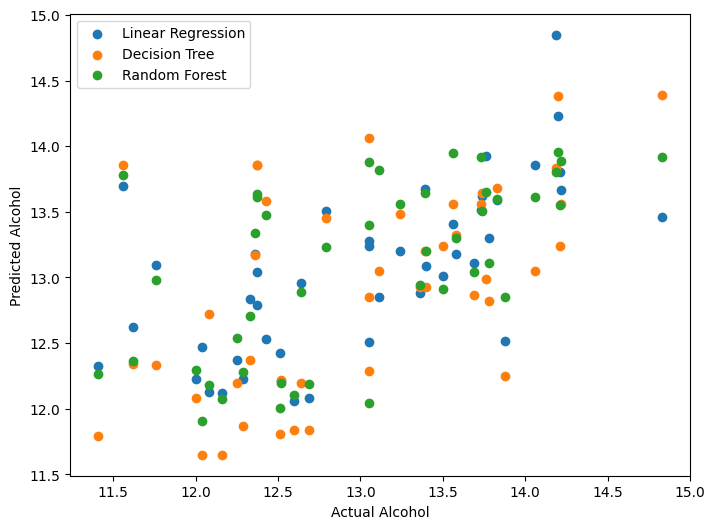

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr, label="Linear Regression")
plt.scatter(y_test, pred_dt, label="Decision Tree")
plt.scatter(y_test, pred_rf, label="Random Forest")

plt.xlabel("Actual Alcohol")
plt.ylabel("Predicted Alcohol")

plt.legend()
plt.show()